In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import io

In [ ]:
!pip install -q transformers datasets jiwer evaluate matplotlib

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.4 MB/s eta 0:00:00


In [ ]:
# Load your pretrained model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update this to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared deco

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

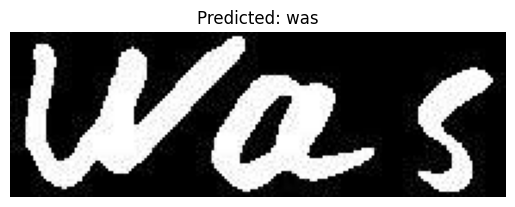

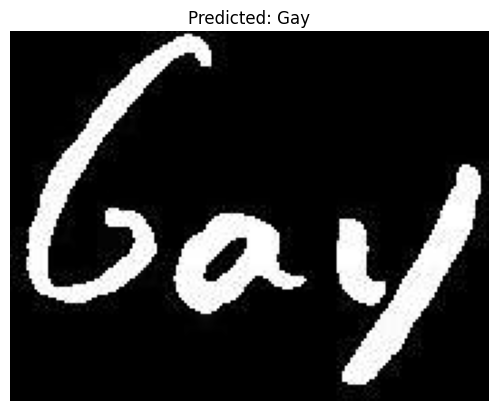

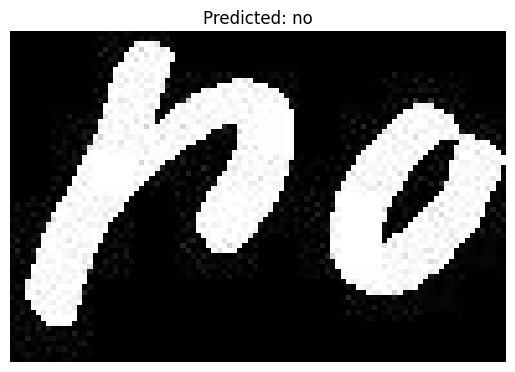

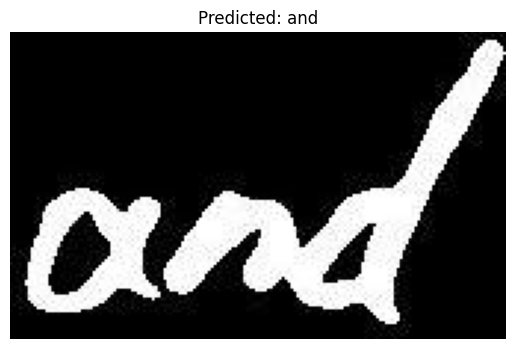

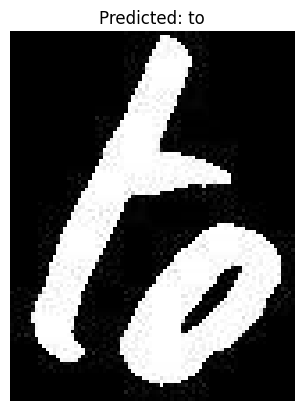

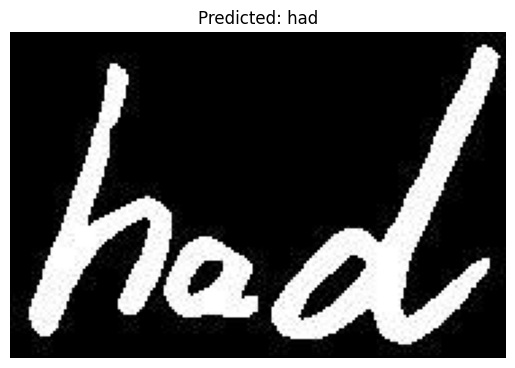

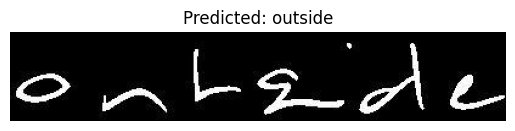

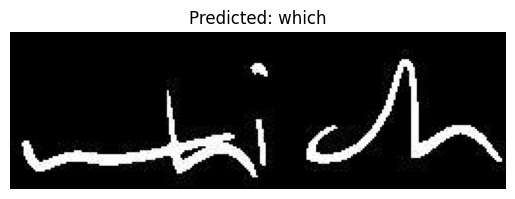

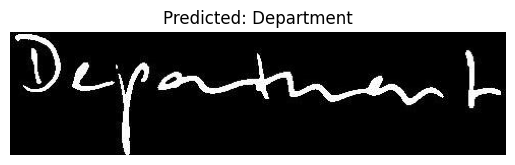

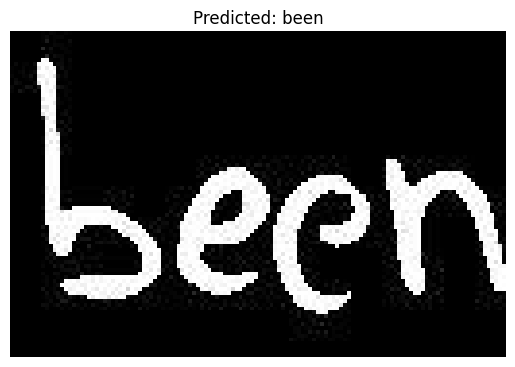

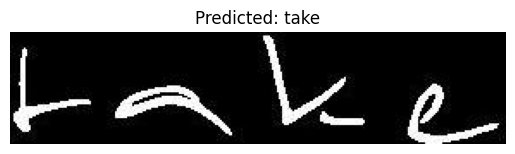

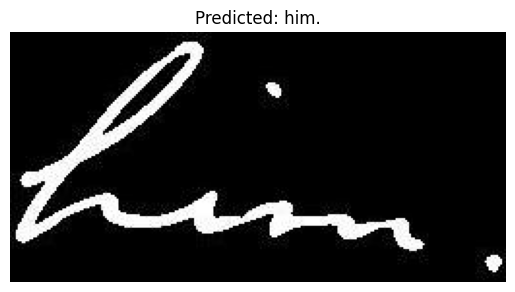

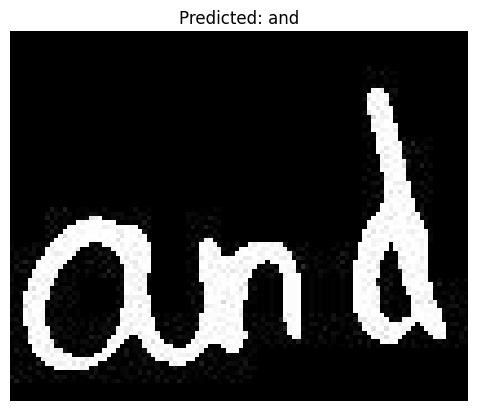

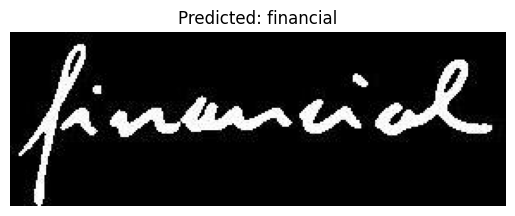

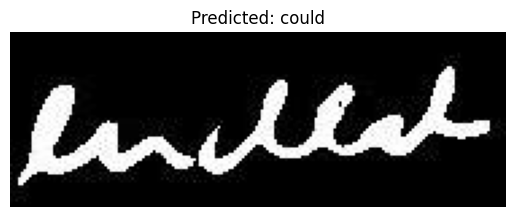

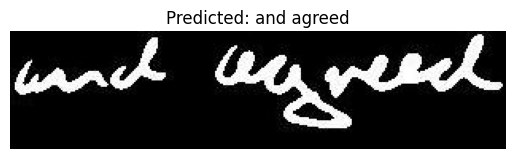

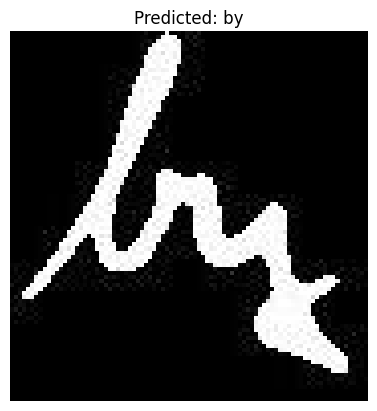

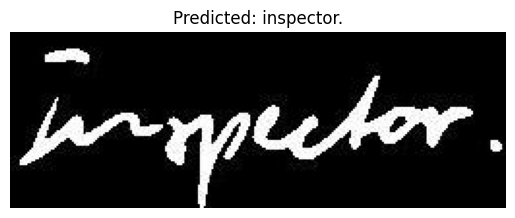

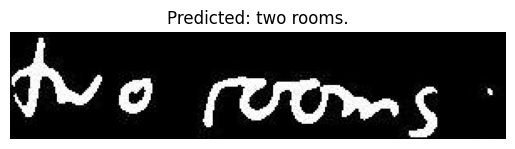

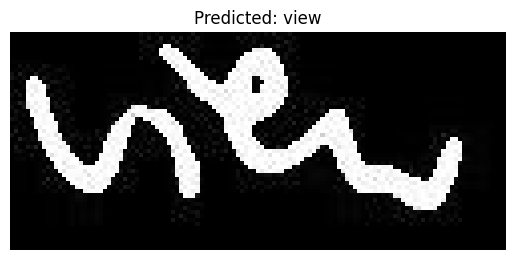

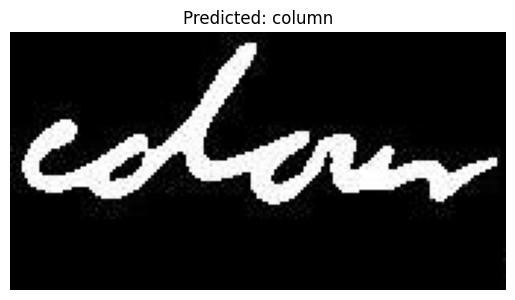

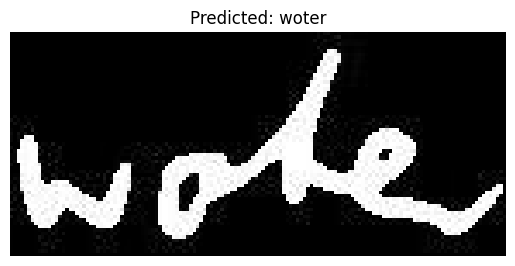

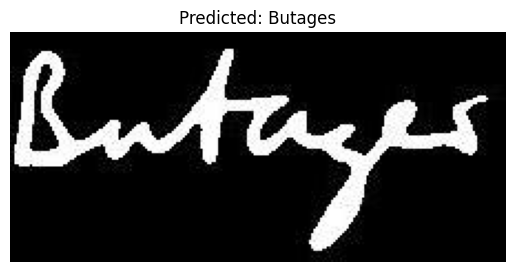

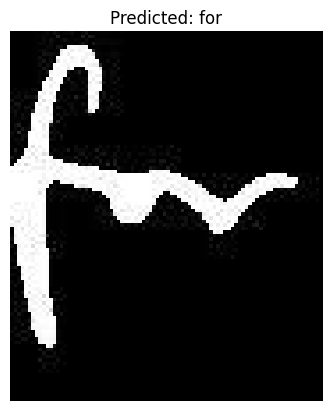

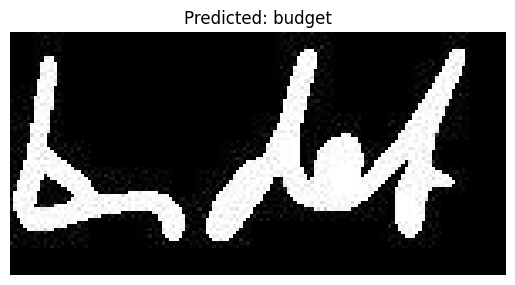

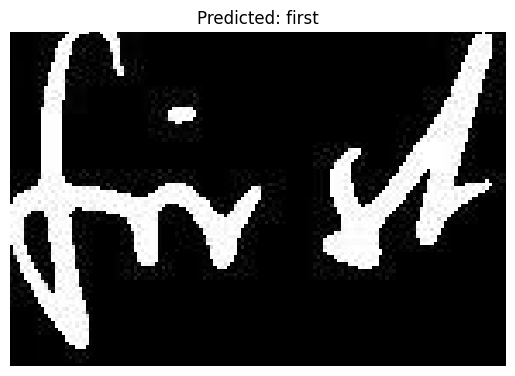

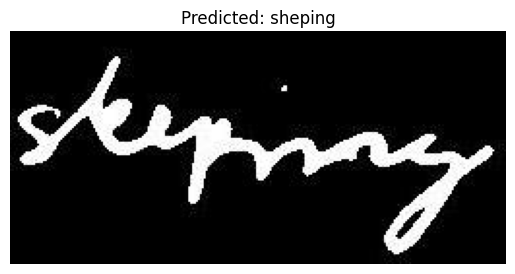

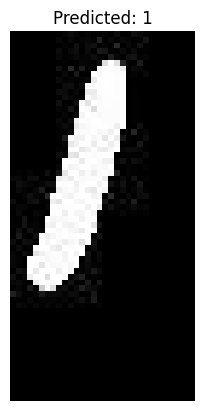

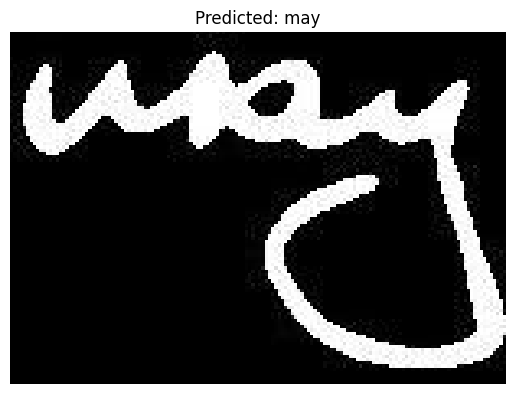

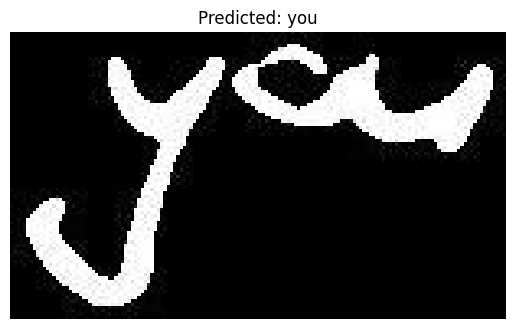

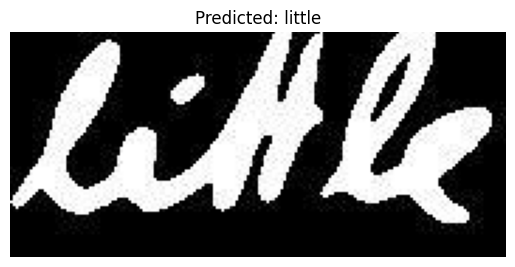

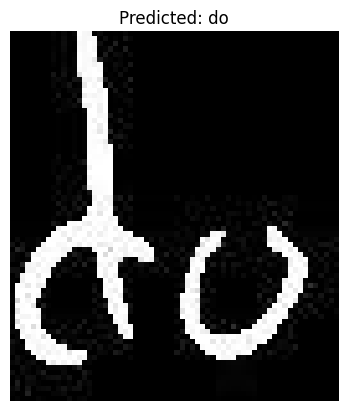

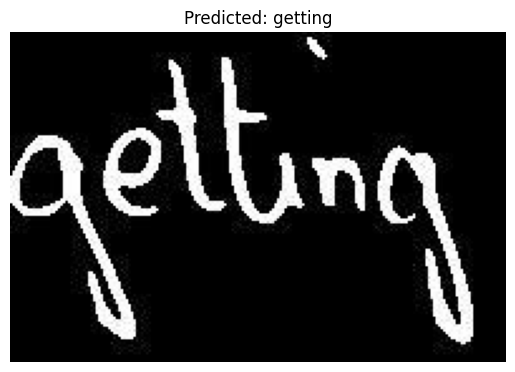

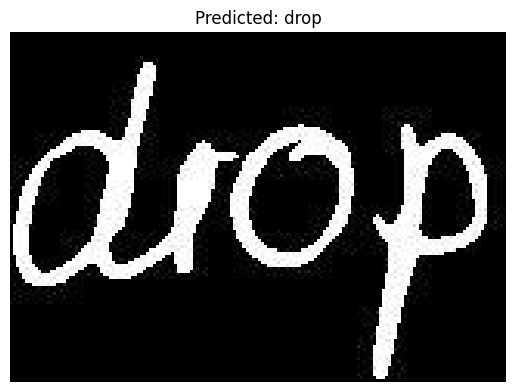

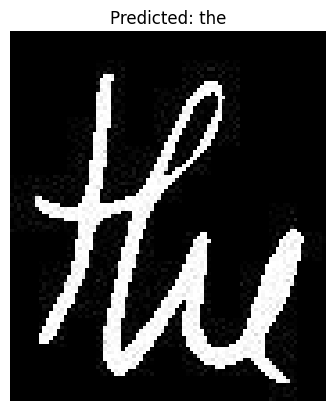

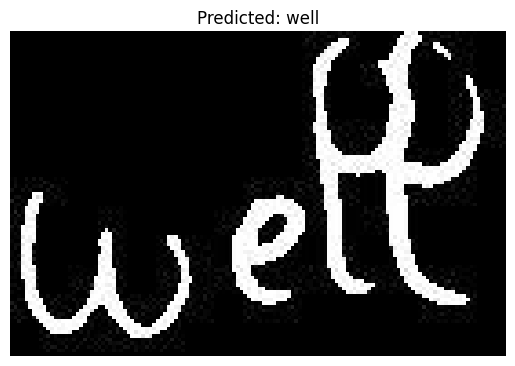

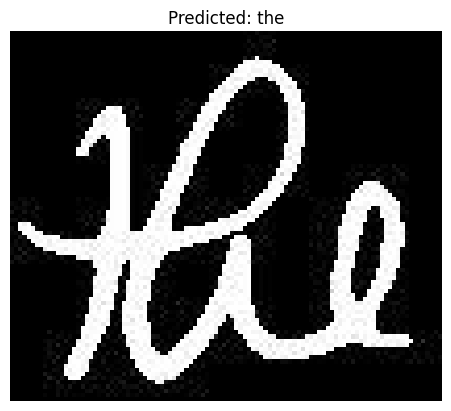

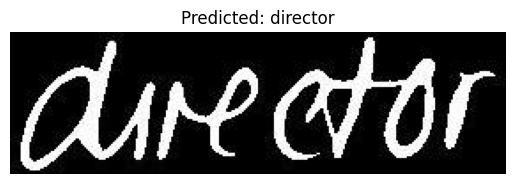

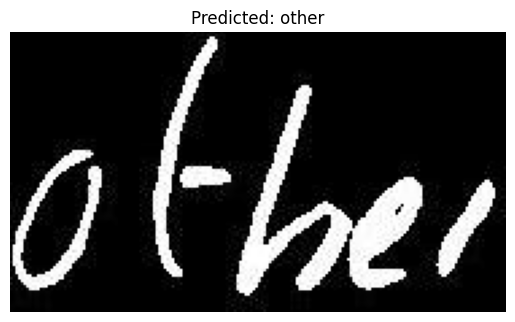

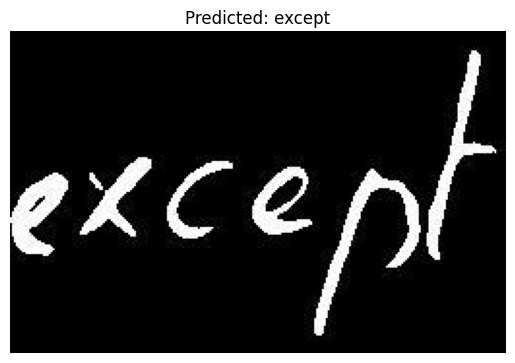

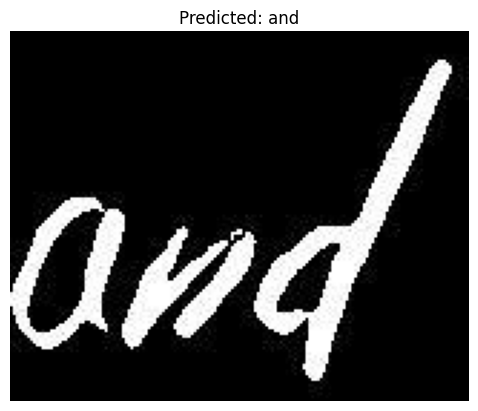

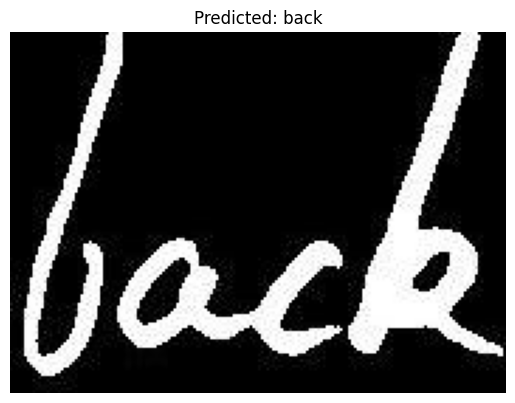

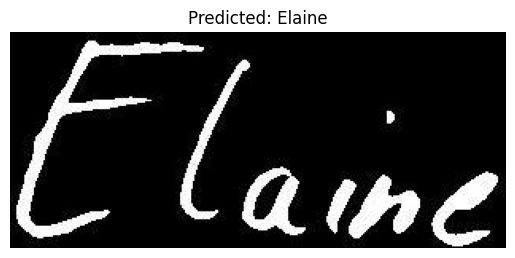

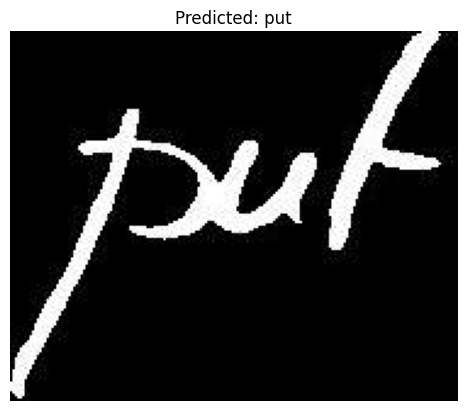

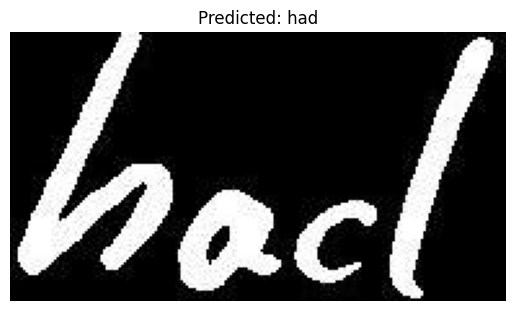

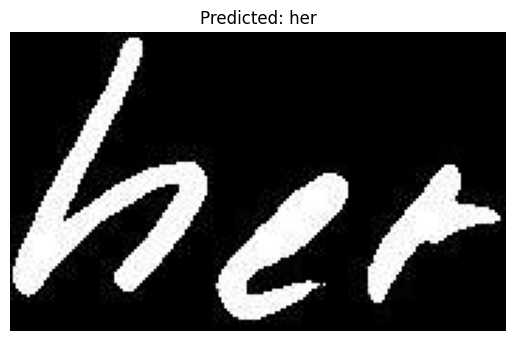

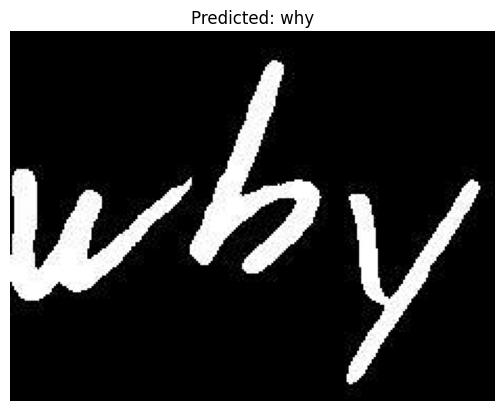

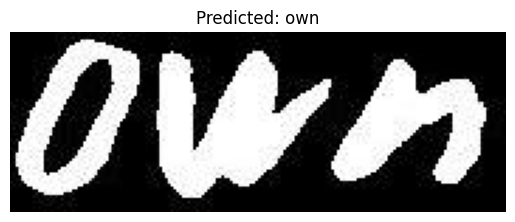

In [ ]:

from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
from PIL import Image
import matplotlib.pyplot as plt

from datasets import load_dataset

validation_dataset = load_dataset("imagefolder", data_dir="/content/drive/MyDrive/words/validation")  # ✅ Load dataset


# Load the trained model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to predict text from an image
def recognize_text(image):
    # Ensure image is RGB
    if isinstance(image, str):  # If it's a file path, open it
        image = Image.open(image).convert("RGB")
    elif isinstance(image, Image.Image):  # If it's a PIL image, convert to RGB
        image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return predicted_text, image

# Test on validation images
for i in range(48):  # Test 5 samples
    img = validation_dataset["train"][i]["image"]  # Load image

    pred_text, img_rgb = recognize_text(img)  # Get prediction & image

    # Display the image
    plt.imshow(img_rgb)
    plt.axis("off")  # Hide axes
    plt.title(f"Predicted: {pred_text}")
    plt.show()

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

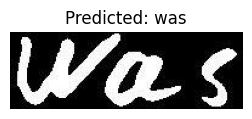

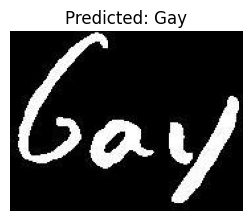

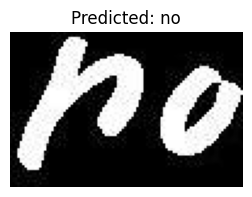

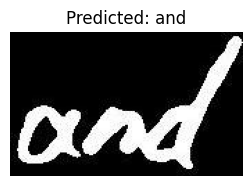

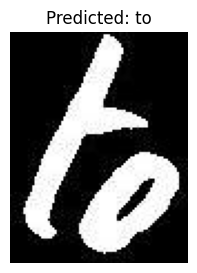

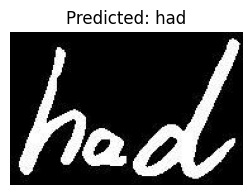

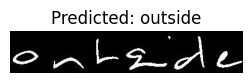

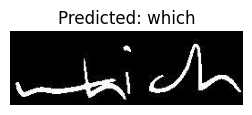

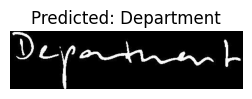

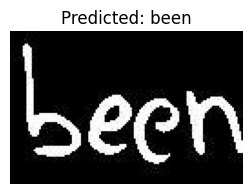

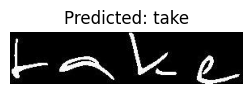

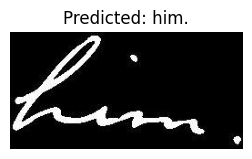

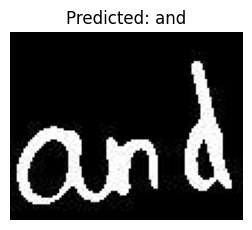

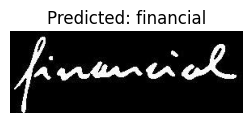

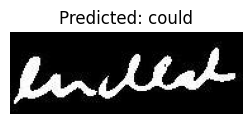

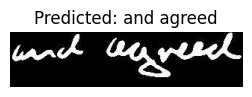

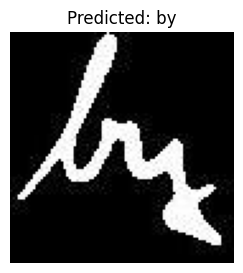

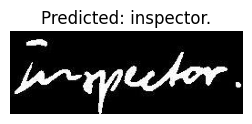

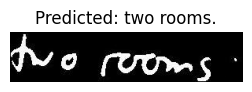

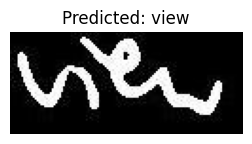

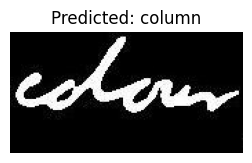

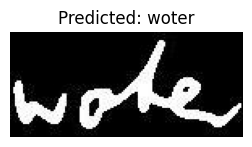

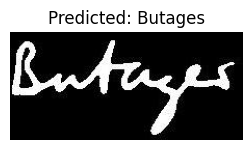

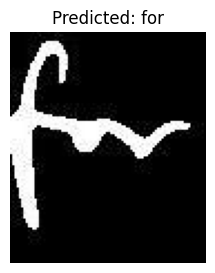

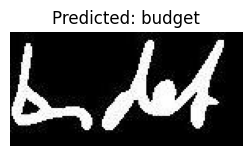

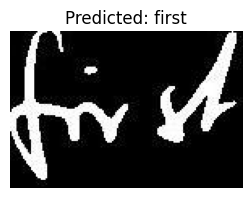

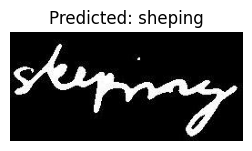

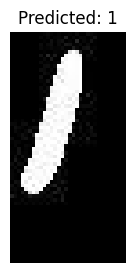

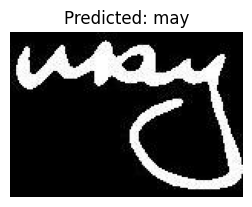

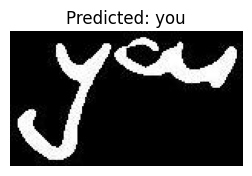

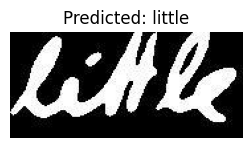

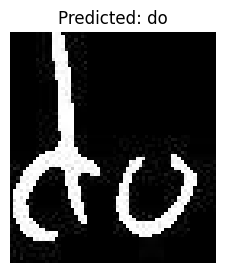

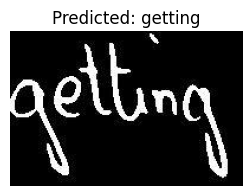

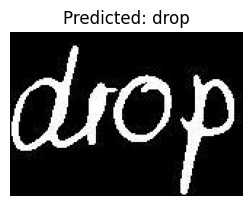

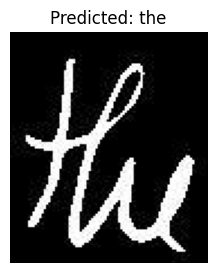

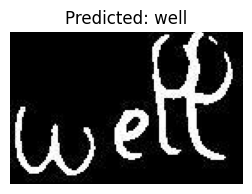

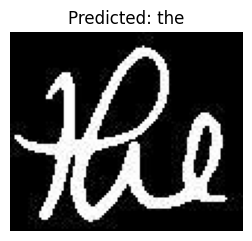

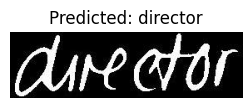

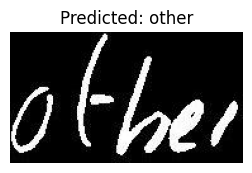

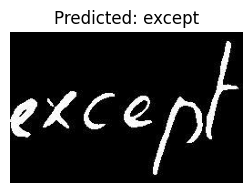

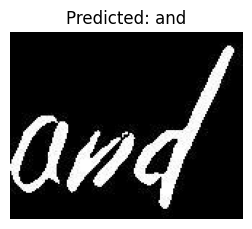

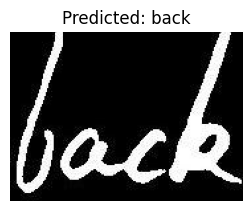

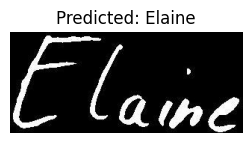

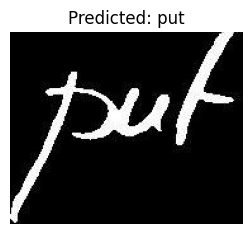

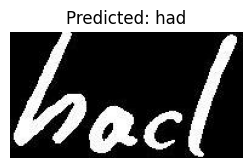

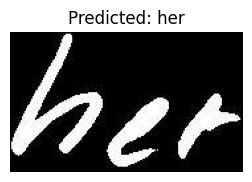

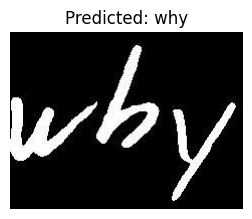

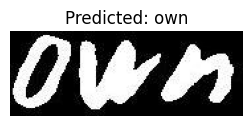

In [ ]:

from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
from PIL import Image
import matplotlib.pyplot as plt

from datasets import load_dataset

validation_dataset = load_dataset("imagefolder", data_dir="/content/drive/MyDrive/words/validation")  # ✅ Load dataset


# Load the trained model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to predict text from an image
def recognize_text(image):
    # Ensure image is RGB
    if isinstance(image, str):  # If it's a file path, open it
        image = Image.open(image).convert("RGB")
    elif isinstance(image, Image.Image):  # If it's a PIL image, convert to RGB
        image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return predicted_text, image

# Test on validation images
for i in range(48):  # Test 5 samples
    img = validation_dataset["train"][i]["image"]  # Load image

    pred_text, img_rgb = recognize_text(img)  # Get prediction & image

    # Display the image
    plt.figure(figsize=(3, 3))
    plt.imshow(img_rgb)
    plt.axis("off")  # Hide axes
    plt.title(f"Predicted: {pred_text}")
    plt.show()

User Input without displaying the image

In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import io

# Load your pretrained model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update this to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Set model to evaluation mode
model.eval()

# Function to recognize text from an image
def recognize_text(image):
    # Convert uploaded file to PIL image
    image = Image.open(image).convert("RGB")

    # Preprocess the image
    pixel_values = processor(image, return_tensors="pt").pixel_values

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    pixel_values = pixel_values.to(device)

    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    # Decode the predicted text
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return predicted_text

# Upload widget
upload = widgets.FileUpload(accept="image/*", multiple=False)
display(upload)

# Button to process uploaded image
def on_upload_change(change):
    for file in upload.value:
        img = io.BytesIO(upload.value[file]['content'])
        recognized_text = recognize_text(img)
        print("\n📝 Recognized Text:", recognized_text)

upload.observe(on_upload_change, names="value")

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

FileUpload(value={}, accept='image/*', description='Upload')


📝 Recognized Text: why

📝 Recognized Text: I Move to stop Mr. Gaiblell from


User Input  displaying the image

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

FileUpload(value={}, accept='image/*', description='Upload')

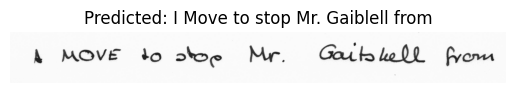


📝 Recognized Text: I Move to stop Mr. Gaiblell from


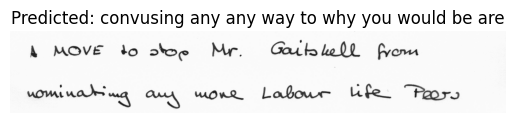


📝 Recognized Text: convusing any any way to why you would be are


In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import io
import matplotlib.pyplot as plt

# Load the pretrained TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Set model to evaluation mode
model.eval()

# Function to recognize text from an image
def recognize_text(image):
    """Processes image and predicts text using TrOCR."""
    # Convert to PIL image
    image = Image.open(image).convert("RGB")

    # Preprocess the image
    pixel_values = processor(image, return_tensors="pt").pixel_values

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    pixel_values = pixel_values.to(device)

    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    # Decode the predicted text
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return predicted_text, image

# Upload widget
upload = widgets.FileUpload(accept="image/*", multiple=False)
display(upload)

# Function to process uploaded image
def on_upload_change(change):
    for file in upload.value:
        img = io.BytesIO(upload.value[file]["content"])

        # Recognize text and get processed image
        recognized_text, img_rgb = recognize_text(img)

        # Display the image
        plt.imshow(img_rgb)
        plt.axis("off")  # Hide axes
        plt.title(f"Predicted: {recognized_text}")
        plt.show()

        # Print recognized text
        print("\n Recognized Text:", recognized_text)

# Observe file upload event
upload.observe(on_upload_change, names="value")


COMBINING PADDLE AND TROCR

In [ ]:
!pip install -q paddleocr paddlepaddle


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.4 MB/s eta 0:00:00


In [ ]:
import os
import torch
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import cv2
import numpy as np

# Load your pretrained TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update with your actual path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Ensure model is in evaluation mode
model.eval()

# Initialize PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang="en")

def extract_text(image_path):
    """
    Extract text using PaddleOCR and refine with TrOCR.
    """
    # Read image
    image = cv2.imread(image_path)

    # Perform OCR with PaddleOCR (detects text regions)
    ocr_results = ocr.ocr(image_path, cls=True)

    full_text = []
    if ocr_results:
        for result in ocr_results:
            if result:
                for line in result:
                    (bbox, (paddle_text, _)) = line
                    x_min, y_min = map(int, bbox[0])
                    x_max, y_max = map(int, bbox[2])

                    # Crop the detected text region
                    cropped_image = image[y_min:y_max, x_min:x_max]

                    # Convert to PIL image
                    pil_image = Image.fromarray(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

                    # Process image for TrOCR
                    pixel_values = processor(pil_image, return_tensors="pt").pixel_values

                    # Perform OCR using TrOCR
                    with torch.no_grad():
                        generated_ids = model.generate(pixel_values)
                    trocr_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

                    # Combine PaddleOCR and TrOCR results
                    refined_text = trocr_text if trocr_text else paddle_text
                    full_text.append(refined_text)

    return "\n".join(full_text)

# Example usage
image_path = "/content/drive/MyDrive/words/validation/0325.png"  # Update with your test image
recognized_text = extract_text(image_path)
print("Recognized Text:\n", recognized_text)


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:16<00:00, 239.40it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:18<00:00, 535.50it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:15<00:00, 133.89it/s]

[2025/03/07 05:57:32] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

[2025/03/07 05:57:35] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.19019007682800293
[2025/03/07 05:57:35] ppocr DEBUG: cls num  : 1, elapsed : 0.0559694766998291
[2025/03/07 05:57:36] ppocr DEBUG: rec_res num  : 1, elapsed : 0.22742676734924316
Recognized Text:
 own


In [ ]:
image_path = "/content/drive/MyDrive/sample.jpeg"  # Update with your test image
recognized_text = extract_text(image_path)
print("Recognized Text:\n", recognized_text)

[2025/03/07 06:03:03] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.763390302658081
[2025/03/07 06:03:03] ppocr DEBUG: cls num  : 4, elapsed : 0.04987907409667969
[2025/03/07 06:03:04] ppocr DEBUG: rec_res num  : 4, elapsed : 0.39351606369018555
Recognized Text:
 small
the of it
Dome


MODIFIED CODE FOR MULTILINE

evaluation metric


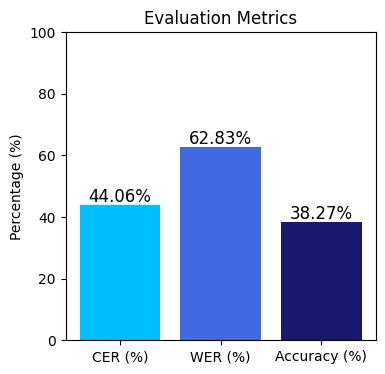

In [ ]:
import matplotlib.pyplot as plt

# Evaluation metrics
metrics = {
    "CER (%)":0.4406 * 100,  # Convert to %
    "WER (%)": 0.6283 * 100,  # Convert to %
    "Accuracy (%)": 0.3827 * 100  # Convert to %
}

# Plot
plt.figure(figsize=(4, 4))
plt.bar(metrics.keys(), metrics.values(), color=["deepskyblue", "royalblue", "midnightblue"])
plt.ylabel("Percentage (%)")
plt.title("Evaluation Metrics")

# Show values on bars
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center", fontsize=12)

plt.ylim(0, 100)  # Ensure y-axis is within 0-100%
plt.show()

RETRY

paddleocr and trocr

[2025/03/08 08:08:44] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

FileUpload(value={}, accept='image/*', description='Upload')

[2025/03/08 08:09:57] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.051824092864990234
[2025/03/08 08:09:57] ppocr DEBUG: cls num  : 4, elapsed : 0.020621299743652344
[2025/03/08 08:09:57] ppocr DEBUG: rec_res num  : 4, elapsed : 0.3199174404144287


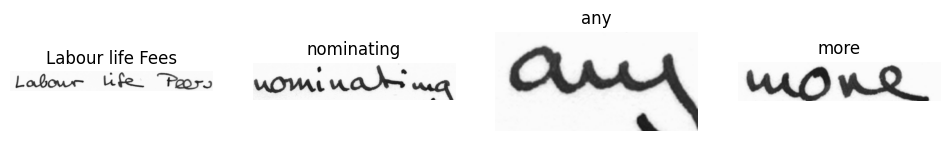


Final Recognized Text: Labour life Fees nominating any more
[2025/03/08 08:13:35] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.046579837799072266
[2025/03/08 08:13:35] ppocr DEBUG: cls num  : 4, elapsed : 0.016387462615966797
[2025/03/08 08:13:35] ppocr DEBUG: rec_res num  : 4, elapsed : 0.2606046199798584


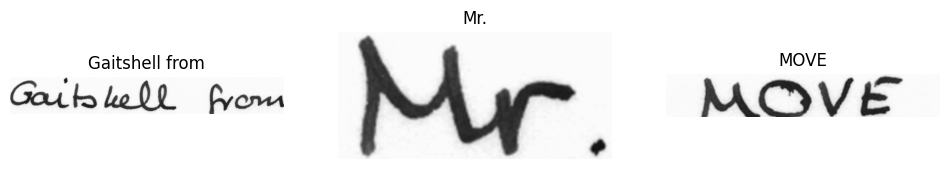


Final Recognized Text: Gaitshell from Mr. MOVE


In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image, ImageOps
import io
import matplotlib.pyplot as plt
import numpy as np
from paddleocr import PaddleOCR

# Load PaddleOCR for line segmentation
ocr = PaddleOCR(use_angle_cls=True, lang='en')

# Load the pretrained TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Set model to evaluation mode
model.eval()

def preprocess_image(image):
    """Convert image to grayscale, apply binarization, and resize."""
    # image = ImageOps.grayscale(image)  # Remove grayscale conversion
    image = image.resize((image.width * 2, image.height * 2), Image.LANCZOS)  # Upscale for better OCR
    return image

def segment_text_regions(image):
    """Use PaddleOCR to detect words and segment them individually."""
    results = ocr.ocr(np.array(image), cls=True)
    segmented_images = []

    if results:
        for line in results:
            for word_info in line:
                bbox, text_info = word_info
                x_min, y_min = map(int, bbox[0])
                x_max, y_max = map(int, bbox[2])
                word_img = image.crop((x_min, y_min, x_max, y_max))
                segmented_images.append(word_img)

    return segmented_images

def recognize_text(image):
    """Processes image and predicts text using TrOCR."""
    # Convert image to RGB if it's not
    if image.mode != 'RGB':
        image = image.convert('RGB')

    pixel_values = processor(image, return_tensors="pt").pixel_values
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    pixel_values = pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return predicted_text

# Upload widget
upload = widgets.FileUpload(accept="image/*", multiple=False)
display(upload)

def on_upload_change(change):
    for file in upload.value:
        img = io.BytesIO(upload.value[file]["content"])
        image = Image.open(img).convert("RGB")

        # Preprocess image
        processed_img = preprocess_image(image)
        segmented_words = segment_text_regions(processed_img)

        final_text = []
        plt.figure(figsize=(12, 6))
        for i, word_img in enumerate(segmented_words):
            text = recognize_text(word_img)
            final_text.append(text)

            # Display segmented words
            plt.subplot(1, len(segmented_words), i + 1)
            plt.imshow(word_img, cmap='gray')
            plt.axis("off")
            plt.title(text)
        plt.show()

        print("\nFinal Recognized Text:", " ".join(final_text))

# Observe file upload event
upload.observe(on_upload_change, names="value")

 trocr alone

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

FileUpload(value={}, accept='image/*', description='Upload')

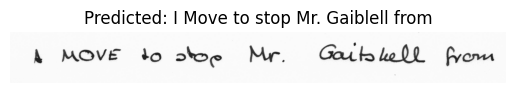


 Recognized Text: I Move to stop Mr. Gaiblell from


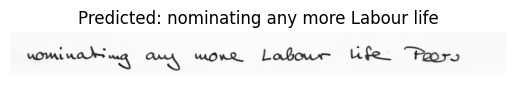


 Recognized Text: nominating any more Labour life


In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import io
import matplotlib.pyplot as plt

# Load the pretrained TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Set model to evaluation mode
model.eval()

# Function to recognize text from an image
def recognize_text(image):
    """Processes image and predicts text using TrOCR."""
    # Convert to PIL image
    image = Image.open(image).convert("RGB")

    # Preprocess the image
    pixel_values = processor(image, return_tensors="pt").pixel_values

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    pixel_values = pixel_values.to(device)

    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    # Decode the predicted text
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return predicted_text, image

# Upload widget
upload = widgets.FileUpload(accept="image/*", multiple=False)
display(upload)

# Function to process uploaded image
def on_upload_change(change):
    for file in upload.value:
        img = io.BytesIO(upload.value[file]["content"])

        # Recognize text and get processed image
        recognized_text, img_rgb = recognize_text(img)

        # Display the image
        plt.imshow(img_rgb)
        plt.axis("off")  # Hide axes
        plt.title(f"Predicted: {recognized_text}")
        plt.show()

        # Print recognized text
        print("\n Recognized Text:", recognized_text)

# Observe file upload event
upload.observe(on_upload_change, names="value")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:16<00:00, 231.19it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:18<00:00, 529.87it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:16<00:00, 130.14it/s]

[2025/03/08 15:49:18] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

[2025/03/08 15:49:19] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2025/03/08 15:49:20] ppocr DEBUG: dt_boxes num : 40, elapsed : 0.5159227848052979
[2025/03/08 15:49:21] ppocr DEBUG: rec_res num  : 40, elapsed : 1.2558774948120117
Extracted 32 lines. Ready for TrOCR recognition!


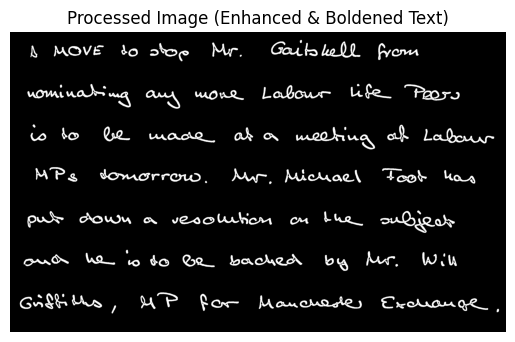

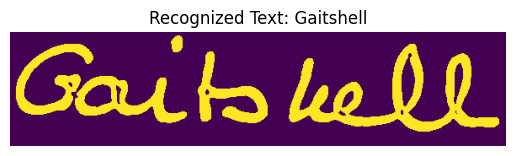

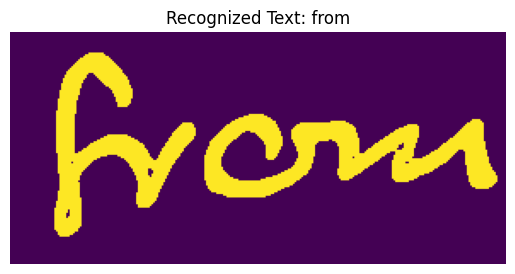

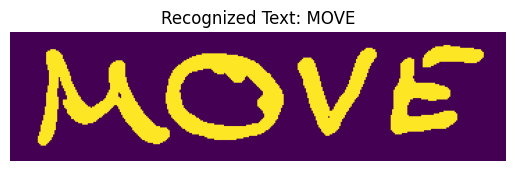

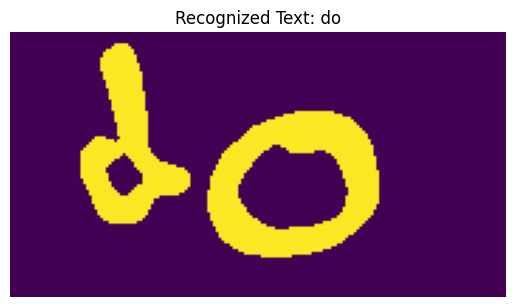

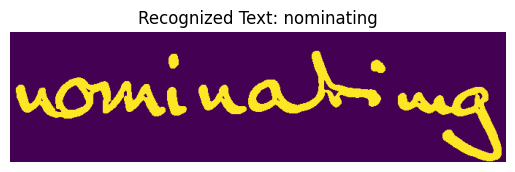

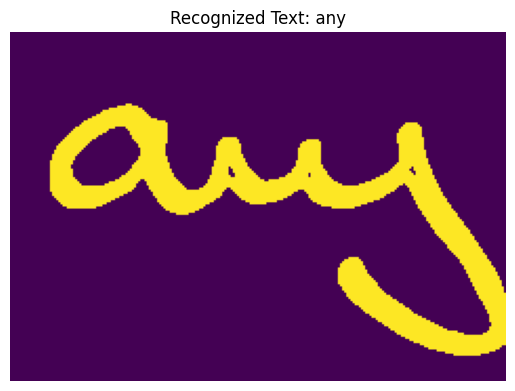

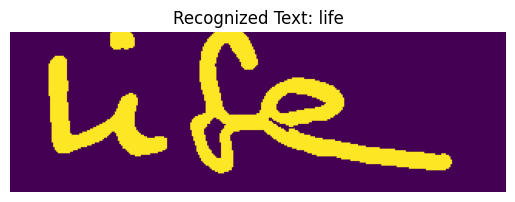

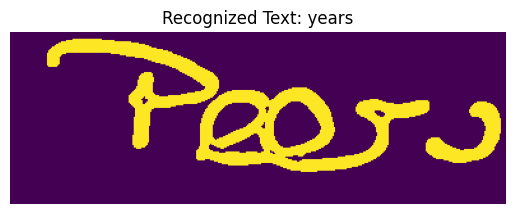

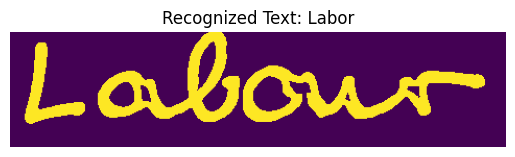

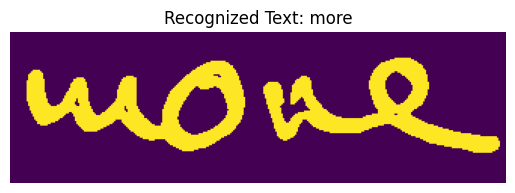

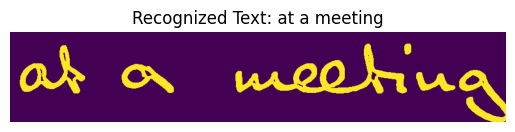

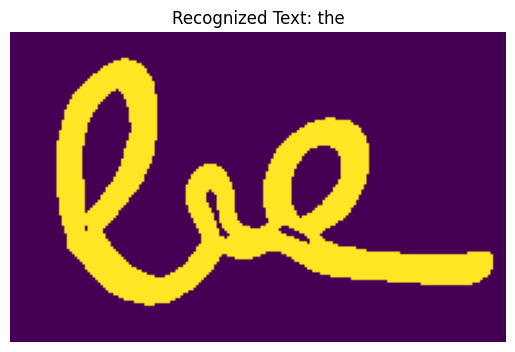

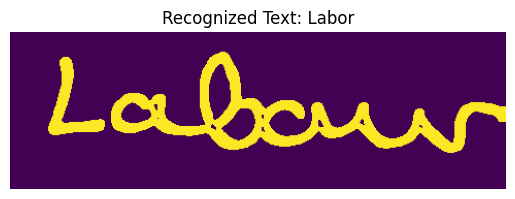

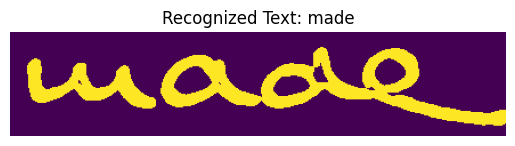

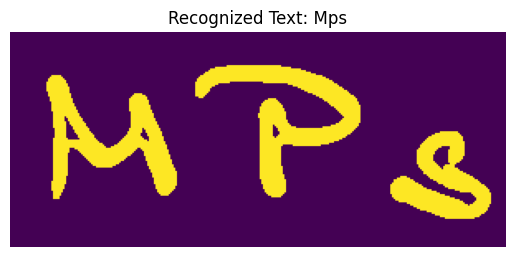

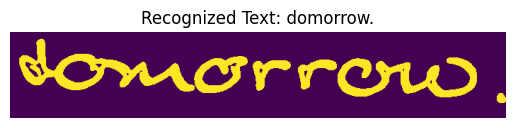

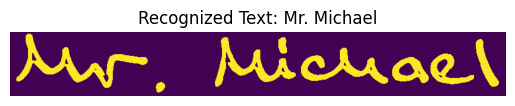

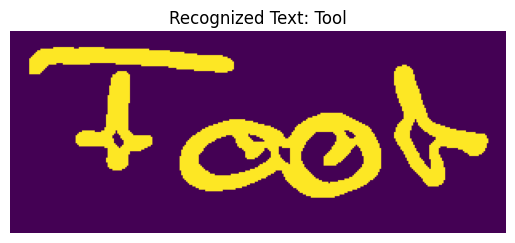

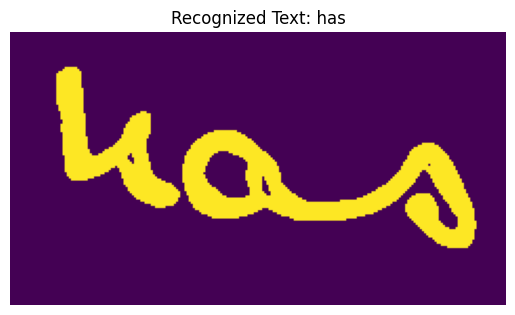

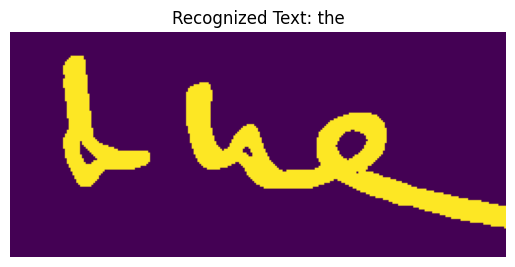

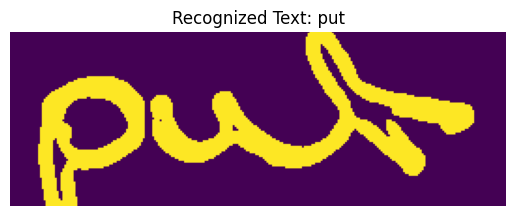

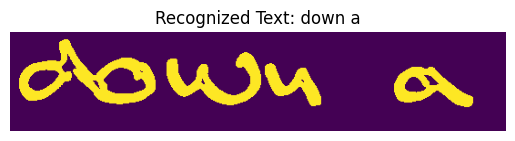

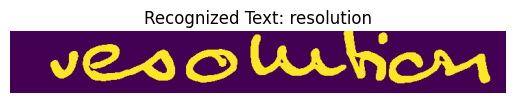

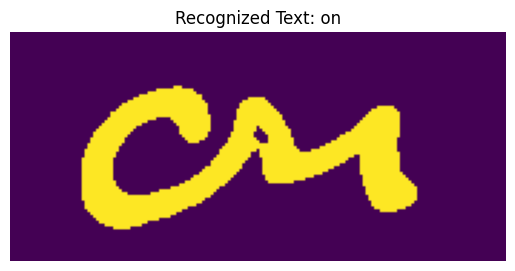

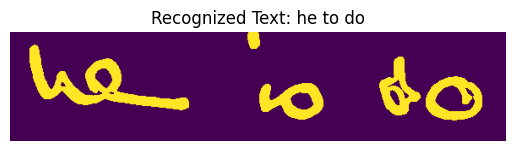

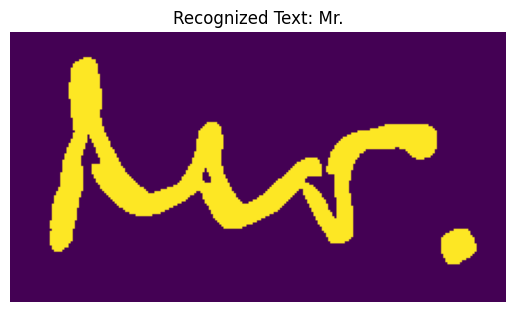

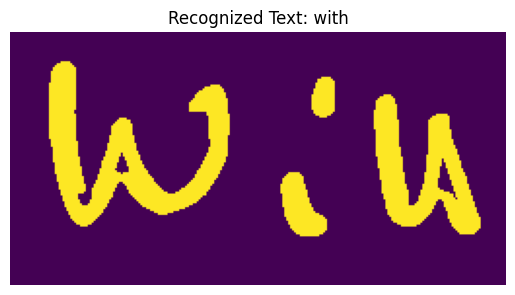

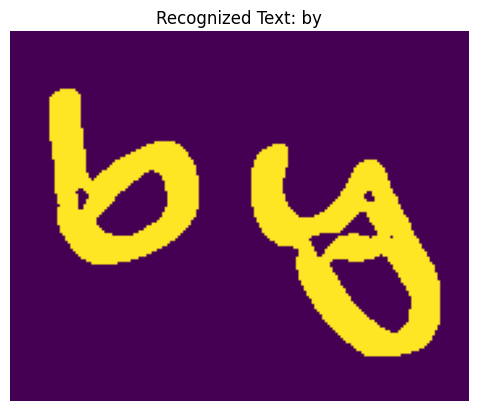

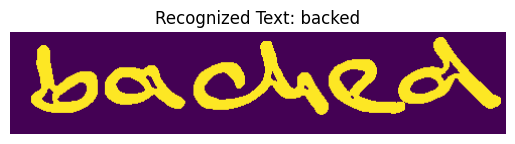

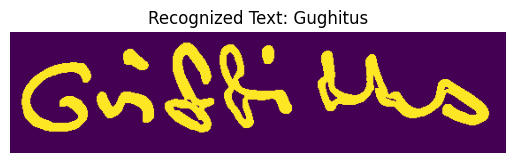

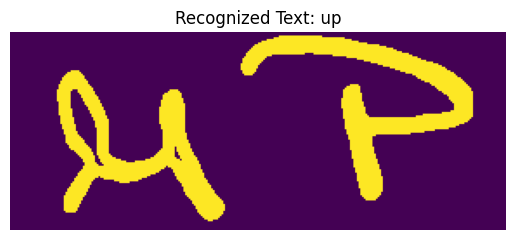

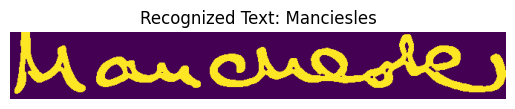

In [ ]:
import cv2
import numpy as np
from PIL import Image
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import os
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
import io

# Load TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()


def preprocess_image(image_path, resize_factor=1.5):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file '{image_path}' not found. Make sure the file is uploaded and the path is correct.")

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Failed to load image '{image_path}'. Check if the image is valid and not corrupted.")

    if resize_factor != 1.0:
        image = cv2.resize(image, None, fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Stronger denoising and CLAHE
    denoised = cv2.fastNlMeansDenoising(gray, h=60)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(denoised)

    # Unsharp masking and morphological enhancement
    blurred = cv2.GaussianBlur(contrast_enhanced, (0, 0), 5)
    sharpened = cv2.addWeighted(contrast_enhanced, 3.0, blurred, -1.5, 0)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 25, 20)

    # Dilation to thicken text
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    bolded = cv2.dilate(binary, dilation_kernel, iterations=2)

    cv2.imwrite("processed_image.png", bolded)

    return bolded, image


def detect_lines(image_path):
    binary_image, resized_image = preprocess_image(image_path)
    ocr = PaddleOCR(lang='en')

    results = ocr.ocr("processed_image.png", cls=True)

    if not results or not results[0]:
        print("No lines detected. Check preprocessing steps or image quality.")
        return [], resized_image

    lines = []
    for result in results[0]:
        bbox, (text, _) = result
        x1, y1 = bbox[0]
        x2, y2 = bbox[2]

        padding = 10
        x1, y1, x2, y2 = int(x1) - padding, int(y1) - padding, int(x2) + padding, int(y2) + padding
        lines.append((x1, y1, x2, y2))

    return lines, binary_image


def extract_and_recognize_lines(lines, image, output_dir='output'):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    line_images = []

    for i, (x1, y1, x2, y2) in enumerate(lines):
        line_img = image[y1:y2, x1:x2]
        line_path = f"{output_dir}/line_{i}.png"
        cv2.imwrite(line_path, line_img)

        pil_img = Image.open(line_path).convert("RGB")
        pixel_values = processor(pil_img, return_tensors="pt").pixel_values

        device = "cuda" if torch.cuda.is_available() else "cpu"
        model.to(device)
        pixel_values = pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
            recognized_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        line_images.append((line_path, recognized_text))

    return line_images


# Example usage
image_path = '/content/drive/MyDrive/example.png'
lines, processed_image = detect_lines(image_path)
line_images = extract_and_recognize_lines(lines, processed_image)

print(f"Extracted {len(line_images)} lines. Ready for TrOCR recognition!")

plt.imshow(cv2.imread("processed_image.png"), cmap='gray')
plt.axis('off')
plt.title("Processed Image (Enhanced & Boldened Text)")
plt.show()

for img_path, text in line_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Recognized Text: {text}")
    plt.show()



Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/08 16:02:45] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

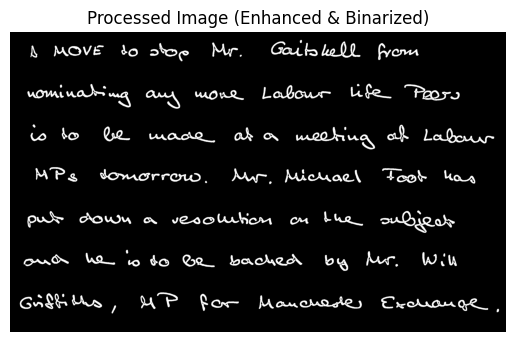

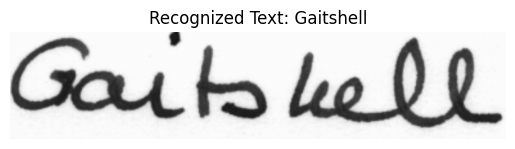

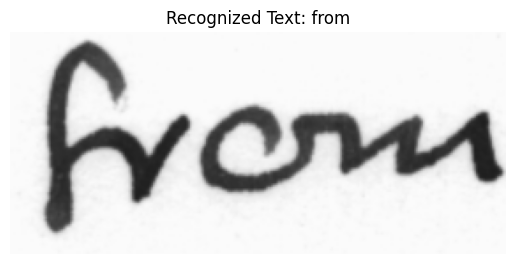

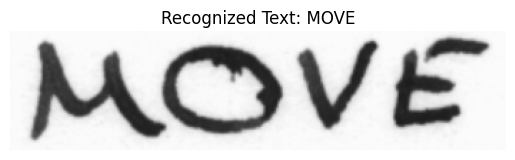

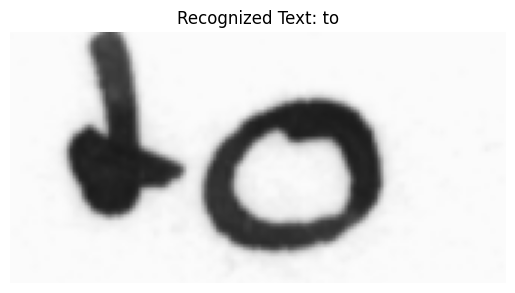

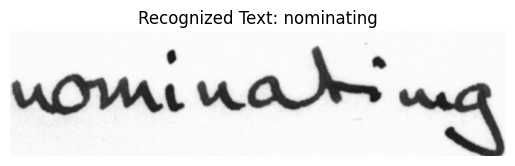

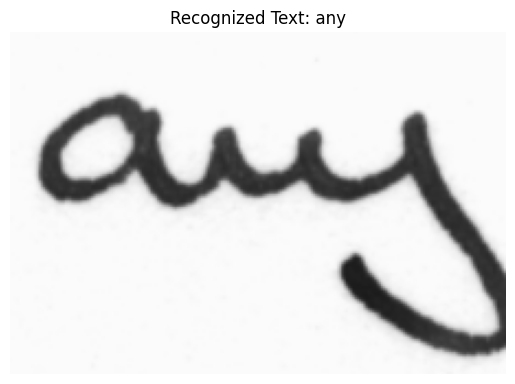

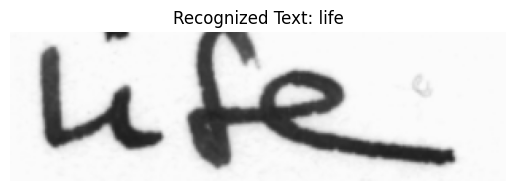

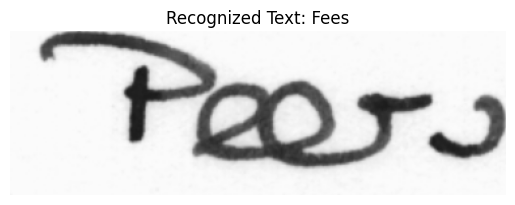

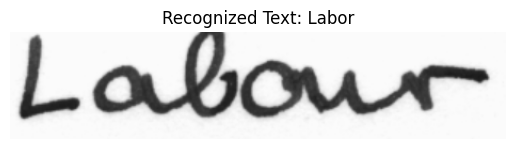

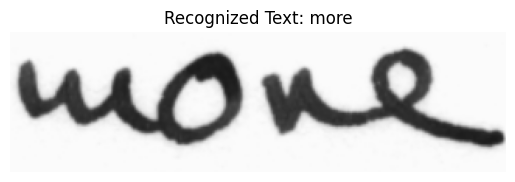

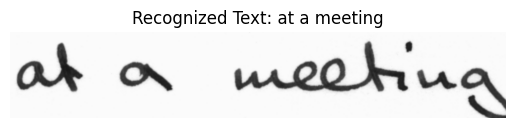

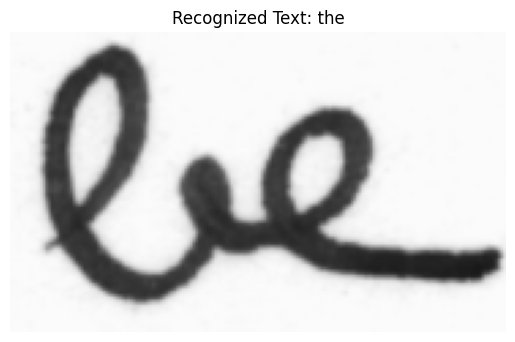

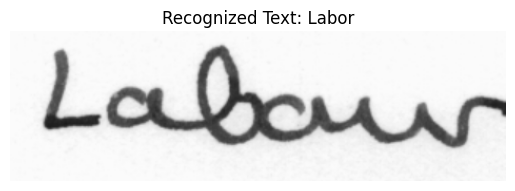

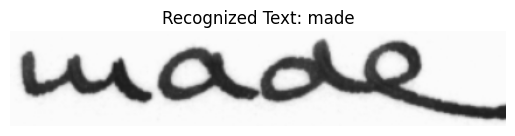

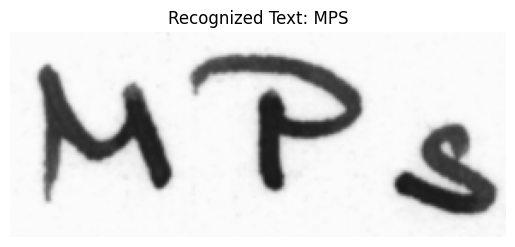

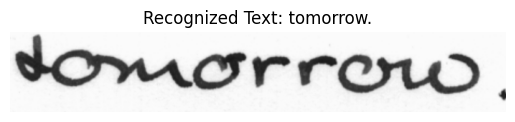

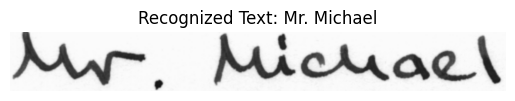

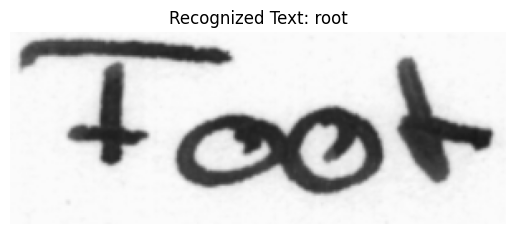

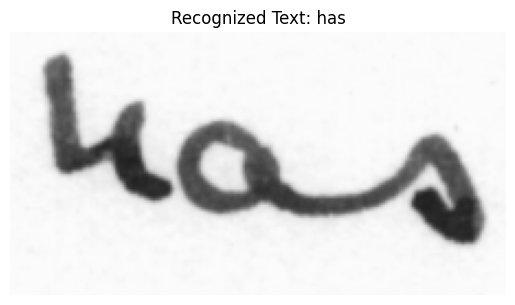

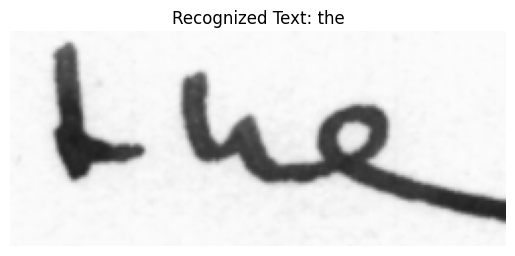

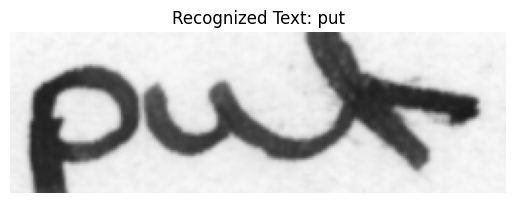

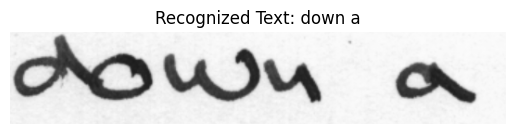

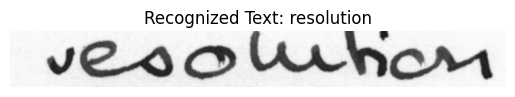

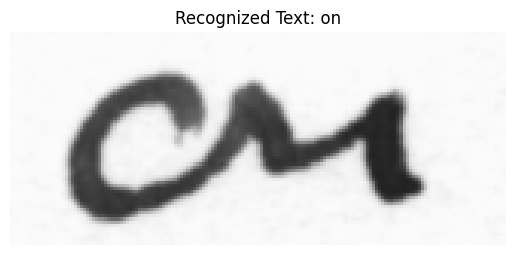

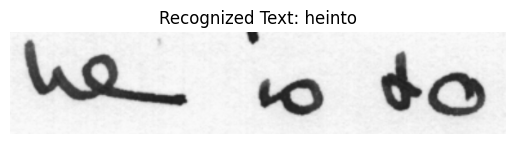

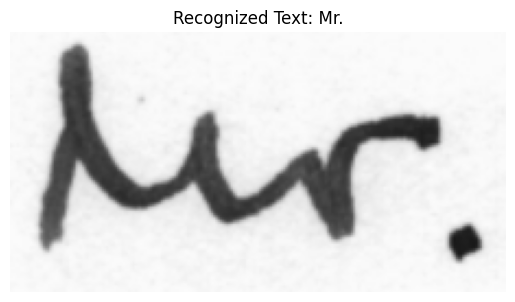

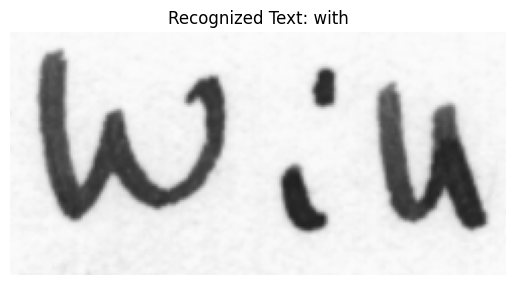

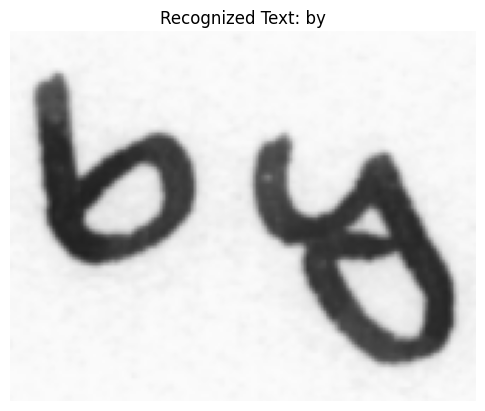

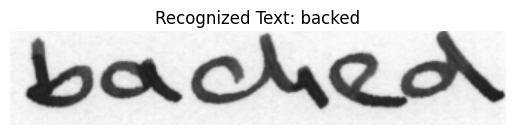

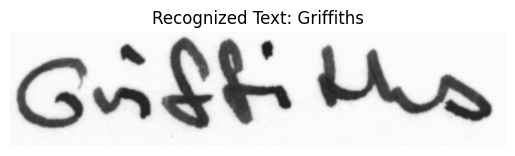

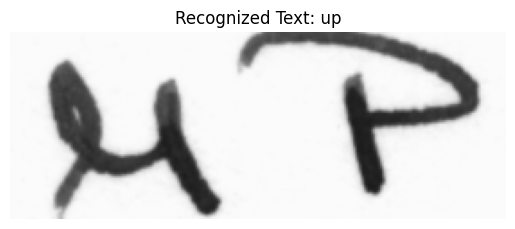

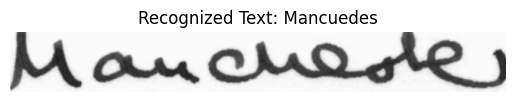

In [ ]:
import cv2
import numpy as np
import torch
import os
from PIL import Image
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Load Fine-tuned TrOCR model
model_path = "/content/drive/MyDrive/trocr_model"  # Update with actual path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def preprocess_image(image_path, resize_factor=1.5):
    """Preprocess image with contrast enhancement, denoising, and binarization."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file '{image_path}' not found.")

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Failed to load image '{image_path}'.")

    if resize_factor != 1.0:
        image = cv2.resize(image, None, fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply denoising
    denoised = cv2.fastNlMeansDenoising(gray, h=60)

    # CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(denoised)

    # Unsharp masking to sharpen text
    blurred = cv2.GaussianBlur(contrast_enhanced, (0, 0), 5)
    sharpened = cv2.addWeighted(contrast_enhanced, 3.0, blurred, -1.5, 0)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 25, 20)

    # Dilation to thicken text
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    bolded = cv2.dilate(binary, dilation_kernel, iterations=2)

    cv2.imwrite("processed_image.png", bolded)

    return bolded, image


def detect_text_regions(image_path):
    """Detect text regions using PaddleOCR and return bounding boxes."""
    binary_image, resized_image = preprocess_image(image_path)
    ocr = PaddleOCR(lang='en')

    results = ocr.ocr("processed_image.png", cls=True)

    if not results or not results[0]:
        print("No text detected. Check preprocessing or image quality.")
        return [], resized_image

    text_regions = []
    for result in results[0]:
        bbox, (text, _) = result
        x1, y1 = bbox[0]
        x2, y2 = bbox[2]

        padding = 5
        x1, y1, x2, y2 = int(x1) - padding, int(y1) - padding, int(x2) + padding, int(y2) + padding
        text_regions.append((x1, y1, x2, y2))

    return text_regions, resized_image


def recognize_text_with_trocr(image_crop):
    """Pass segmented text images to the fine-tuned TrOCR model."""
    pil_img = Image.fromarray(image_crop).convert("RGB")
    pixel_values = processor(pil_img, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values, num_beams=4)
        recognized_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return recognized_text


def extract_and_recognize_text(text_regions, image, output_dir='output'):
    """Extract text regions and recognize them using TrOCR."""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    recognized_texts = []

    for i, (x1, y1, x2, y2) in enumerate(text_regions):
        text_crop = image[y1:y2, x1:x2]
        text_path = f"{output_dir}/text_{i}.png"
        cv2.imwrite(text_path, text_crop)

        recognized_text = recognize_text_with_trocr(text_crop)
        recognized_texts.append((text_path, recognized_text))

    return recognized_texts


# **🔹 Example usage**
image_path = "/content/drive/MyDrive/example.png"

# Step 1: Detect text regions
text_regions, processed_image = detect_text_regions(image_path)

# Step 2: Extract text and recognize using TrOCR
recognized_texts = extract_and_recognize_text(text_regions, processed_image)

print(f"Extracted {len(recognized_texts)} text regions. Ready for TrOCR recognition!")

# Step 3: Display processed image
plt.imshow(cv2.imread("processed_image.png"), cmap='gray')
plt.axis('off')
plt.title("Processed Image (Enhanced & Binarized)")
plt.show()

# Step 4: Display each recognized text with its extracted image
for img_path, text in recognized_texts:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Recognized Text: {text}")
    plt.show()


In [ ]:
import pandas as pd
import torch
import os
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
from datasets import load_dataset
import evaluate

# Load TrOCR Model
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# ✅ Load dataset (Images only)
eval_dataset = load_dataset("imagefolder", data_dir="/content/drive/MyDrive/words/validation")

# ✅ Load labels from CSV (Manually map images to labels)
label_file = "/content/drive/MyDrive/words/test.txt"
df_labels = pd.read_csv(label_file, sep="\t", header=None, names=["file_name", "text"])

# Create a dictionary to map filenames to labels
label_dict = dict(zip(df_labels["file_name"], df_labels["text"]))

# ✅ Function to compute validation accuracy
def compute_validation_accuracy(eval_dataset, label_dict, batch_size=4):
    correct = 0
    total = 0
    predictions = []
    references = []

    for i in range(0, len(eval_dataset["train"]), batch_size):
        batch = eval_dataset["train"][i : i + batch_size]
        images = []
        labels = []

        for sample in batch["image"]:
            image = sample.convert("RGB")
            filename = sample.filename.split("/")[-1]  # Extract filename
            if filename in label_dict:
                labels.append(label_dict[filename])
                images.append(processor(image, return_tensors="pt").pixel_values.to(device))

        if not images:  # Skip if no valid labels found
            continue

        # Convert images to tensor
        images = torch.cat(images)

        with torch.no_grad():
            generated_ids = model.generate(images)

        pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)

        # Compute accuracy
        for pred, label in zip(pred_texts, labels):
            if pred.strip().lower() == label.strip().lower():
                correct += 1
            total += 1

        predictions.extend(pred_texts)
        references.extend(labels)

    # Compute accuracy, CER & WER
    accuracy = correct / total if total > 0 else 0.0
    cer = evaluate.load("cer").compute(predictions=predictions, references=references)
    wer = evaluate.load("wer").compute(predictions=predictions, references=references)

    return {"Validation Accuracy": accuracy, "CER": cer, "WER": wer}

# ✅ Run evaluation
results = compute_validation_accuracy(eval_dataset, label_dict)
print("\n📊 Validation Metrics:")
print(f"✅ Validation Accuracy: {results['Validation Accuracy'] * 100:.2f}%")
print(f"❌ Character Error Rate (CER): {results['CER']:.4f}")
print(f"❌ Word Error Rate (WER): {results['WER']:.4f}")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

AttributeError: 'Image' object has no attribute 'filename'